# TINDER for TREES - Earth Day 

Computer Science

Demo Topic

The project I would like to build is around publicly accessible tree data. I did a Masters in Climate Science (which is where I had to use R-studio), and have had this idea for a while that I haven't been able to execute on - which comes to mind again every year in April as we're headed into Earth Day.


The general idea:
- there are a ton of open source data sources containing tree location data, and size. National champion tree program in the US. Treeregister.org for the UK. Ancient Tree Inventory also in the UK. etc
- There's a website called opentrees.org, which has build something similar to this but its a bit outdated, and not actively managed (I've messaged with the builder of it a little on GitHub and over Twitter)
- I'd like to make an app that is framed like a dating app, where you swipe left and right on trees in your area and setup a "date" (e.g. go and visit one on earth day).
- bit of a nature appreciation idea
- earth day is in like 2 weeks, so that might not be realistic to pull off of course, but this just tends to be an April idea that keeps popping up

Details

I am looking for Computer programming tutor. I've made a few attempts at doing on my own, including programs like Codedex, but I keep running into roadblocks where I could use some personal instruction I think. I've done a bit of coding with R-studio for a Masters degree, but that doesn't really ext...

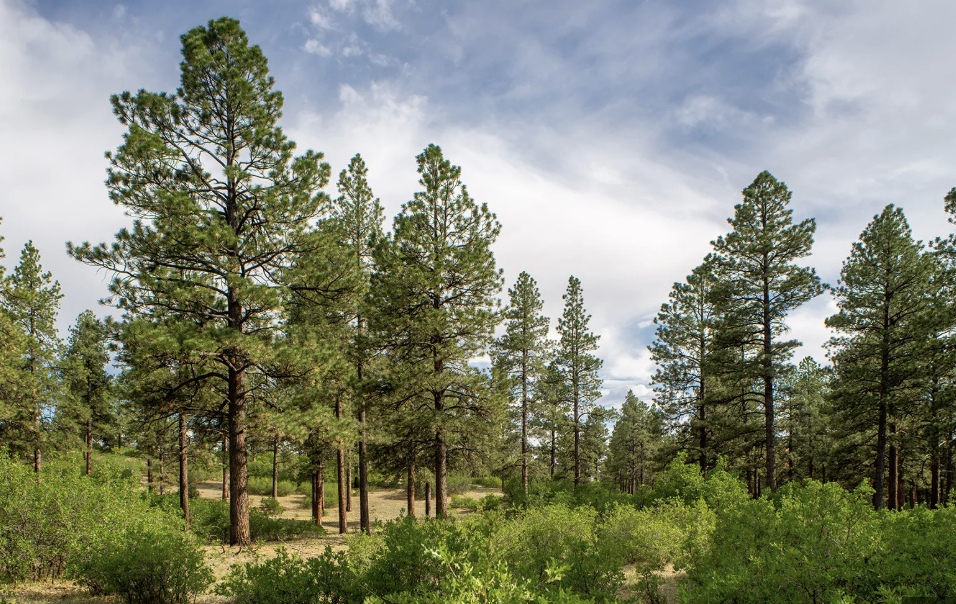

In [1]:
#### start 

### recommend python 

### finding the data. : sources   US. Treeregister.org for the UK. Ancient Tree Inventory also in the UK.

### W PICTURES 



# GENERATE DATA 

In [3]:
# -----######-----######-----######-----######-----######
# GENERATE 5000 TREES WORLDWIDE + NUMERIC CODE
# -----######-----######-----######-----######-----######

import pandas as pd
import numpy as np
from tqdm import tqdm

n_trees = 50000

rows = []

for i in tqdm(range(n_trees), desc="🌍 Generating Global Trees"):

    # 🌍 GLOBAL GEO (uniform distribution)
    u = np.random.uniform(0, 1)
    v = np.random.uniform(0, 1)

    lat = np.degrees(np.arcsin(2*u - 1))   # correct distribution
    lon = 360 * v - 180

    # 🧠 NUMERIC CODE
    tree_code = 100000 + i

    rows.append({
        "tree_code": tree_code,
        "tree_id": f"tree_{i+1}",
        "common_name": f"Tree_{i+1}",
        "species": "Unknown",
        "latitude": lat,
        "longitude": lon,
        "height_m": np.random.randint(5, 35),
        "age_years": np.random.randint(5, 200)
    })

df = pd.DataFrame(rows)

# 🔥 optional sort
df = df.sort_values("tree_code").reset_index(drop=True)

len(df)

🌍 Generating Global Trees: 100%|███████████████████████████████████| 50000/50000 [00:00<00:00, 156233.85it/s]


50000

# check df 

In [5]:
df.head()

,tree_code,tree_id,common_name,species,latitude,longitude,height_m,age_years
0,100000,tree_1,Tree_1,Unknown,17.089161,-149.772734,5,180
1,100001,tree_2,Tree_2,Unknown,-37.986787,-106.943728,28,171
2,100002,tree_3,Tree_3,Unknown,-55.617719,78.209964,6,100
3,100003,tree_4,Tree_4,Unknown,-50.244784,-120.956554,33,78
4,100004,tree_5,Tree_5,Unknown,55.899954,-45.940709,7,117


# FIND MATCHES 

In [10]:
import pandas as pd
import numpy as np
import random

# ---- haversine (FIXED: now defined) ----
def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c

# ---- random point ----
def _geo_1004_rand_GET_point():
    return random.uniform(-90, 90), random.uniform(-180, 180)

# ---- main function ----
def _tree_1004_i4_GET_geo_swipe_smart(
    df,
    user_lat=None,
    user_lon=None,
    radius_km=50,
    n_show=30
):

    if user_lat is None or user_lon is None:
        user_lat, user_lon = _geo_1004_rand_GET_point()
        print(f"\n🌍 RANDOM LOCATION: ({round(user_lat,4)}, {round(user_lon,4)})")
    else:
        print(f"\n📍 USER LOCATION: ({user_lat}, {user_lon})")

    df = df.copy()

    df["dist_km"] = haversine_vec(
        user_lat,
        user_lon,
        df["latitude"].values,
        df["longitude"].values
    )

    df = df[df["dist_km"] <= radius_km]

    if df.empty:
        print("\n⚠️ No trees found within radius")
        return pd.DataFrame(), pd.DataFrame()

    df_near = df.sort_values("dist_km").head(n_show)
    trees = df_near.to_dict(orient="records")

    matches = []
    decisions = []

    print("\n🌳 START SWIPING 🌳")

    for tree in trees:

        print("\n" + "-"*40)
        print(f"🌳 {tree['common_name']}")
        print(f"📏 {tree['height_m']} m | 🌱 {tree['age_years']} yrs")
        print(f"📍 {round(tree['dist_km'],2)} km")

        choice = input("👉 y / n / q: ").lower().strip()

        if choice == "y":
            matches.append(tree)
            decisions.append("yes")
            print("❤️ MATCHED")

        elif choice == "n":
            decisions.append("no")

        elif choice == "q":
            break

        else:
            decisions.append("no")

    df_matches = pd.DataFrame(matches)

    df_decisions = df_near.iloc[:len(decisions)].copy()
    df_decisions["decision"] = decisions

    print(f"\nViewed: {len(decisions)} | Matched: {len(matches)}")

    return df_matches, df_decisions

# ---- RUN ----
df_matches, df_decisions = _tree_1004_i4_GET_geo_swipe_smart(
    df,
    user_lat=42.44,
    user_lon=-82.90,
    radius_km=100
)


📍 USER LOCATION: (42.44, -82.9)

🌳 START SWIPING 🌳

----------------------------------------
🌳 Tree_14427
📏 29 m | 🌱 142 yrs
📍 30.23 km


👉 y / n / q:  y


❤️ MATCHED

----------------------------------------
🌳 Tree_32272
📏 13 m | 🌱 69 yrs
📍 82.08 km


👉 y / n / q:  y


❤️ MATCHED

----------------------------------------
🌳 Tree_3688
📏 30 m | 🌱 183 yrs
📍 86.84 km


👉 y / n / q:  q



Viewed: 2 | Matched: 2


# check mathced ones 

In [11]:
df_decisions

,tree_code,tree_id,common_name,species,latitude,longitude,height_m,age_years,dist_km,decision
14426,114426,tree_14427,Tree_14427,Unknown,42.168614,-82.878511,29,142,30.228465,yes
32271,132271,tree_32272,Tree_32272,Unknown,42.548925,-83.890159,13,69,82.079979,yes
